In [1]:
print("Hello854848485")

Hello854848485


🐍 Python for Network Engineers — Day 12: Talking to APIs with the requests library
Part 1 — The concept & why it matters
Yesterday (Day 11) you learned to read JSON. Today you learn where that JSON usually comes from: REST APIs.
Almost every modern network platform — Catalyst Center (DNA Center), Meraki Dashboard, Arista CloudVision, NSX, Panorama, even Azure — exposes a REST API over HTTPS. Instead of SSH-ing in and screen-scraping CLI text, you send an HTTP request to a URL and get back clean, structured JSON. No regex parsing of "show" output, no fragile text matching — just data.
The standard tool for this in Python is the requests library. The four things to know:
Method — GET reads data (list devices), POST creates/changes, PUT/DELETE update/remove.
Headers — usually carry your auth token, e.g. {"Authorization": "Bearer ..."} or an API-key header.
Status code — resp.status_code. 200 = OK, 401 = bad auth, 404 = not found, 500 = server error. Always check it.
Body — resp.json() turns the JSON response straight into a Python dict/list (ties right back to Day 11).
This is the single most useful skill for real network automation — it's how you pull inventory, push config, and read telemetry at scale.
Part 2 — Example code
Example 1 — A basic GET: fetch a list of devices and check the result
import requests
url = "https://api.meraki.com/api/v1/organizations/12345/devices"
headers = {"Authorization": "Bearer YOUR_API_TOKEN"}
resp = requests.get(url, headers=headers)
if resp.status_code == 200:          # always check before trusting the body
    devices = resp.json()            # JSON -> Python list of dicts (Day 11!)
    print(f"Found {len(devices)} devices")
    for d in devices:
        print(f"{d['name']:<20}{d['model']:<12}{d['serial']}")
else:
    print(f"Request failed: {resp.status_code}")

Example 2 — A GET with query parameters (filtering)
params = {"status": "online"}        # becomes ?status=online in the URL
resp = requests.get(url, headers=headers, params=params, timeout=10)
resp.raise_for_status()              # shortcut: raises an error on 4xx/5xx
online = resp.json()
print(f"{len(online)} devices online")

Example 3 — A POST: send JSON to change something
payload = {"name": "edge-rtr-02", "tags": ["wan", "prod"]}
resp = requests.post(url, headers=headers, json=payload, timeout=10)
#   json=payload  -> requests serializes the dict AND sets Content-Type for you
print(resp.status_code)              # 201 Created / 200 OK on success

Part 3 — Practice question
You're given:
import requests
url = "https://controller.example.com/api/v1/interfaces"
token = "abc123"

Write the code to:
Send a GET request to url with the header {"X-Auth-Token": token} and a 10-second timeout.
If the status code is 200, parse the JSON (assume it's a list of interface dicts) and print how many interfaces came back.
Otherwise, print Error: followed by the status code.
👉 Hint: requests.get(url, headers=..., timeout=10), then check resp.status_code == 200 and use len(resp.json()).
Reply with your answer whenever you like — tomorrow we'll build on this and look at handling auth tokens & pagination! 🚀
Microsoft Internal Python Notes



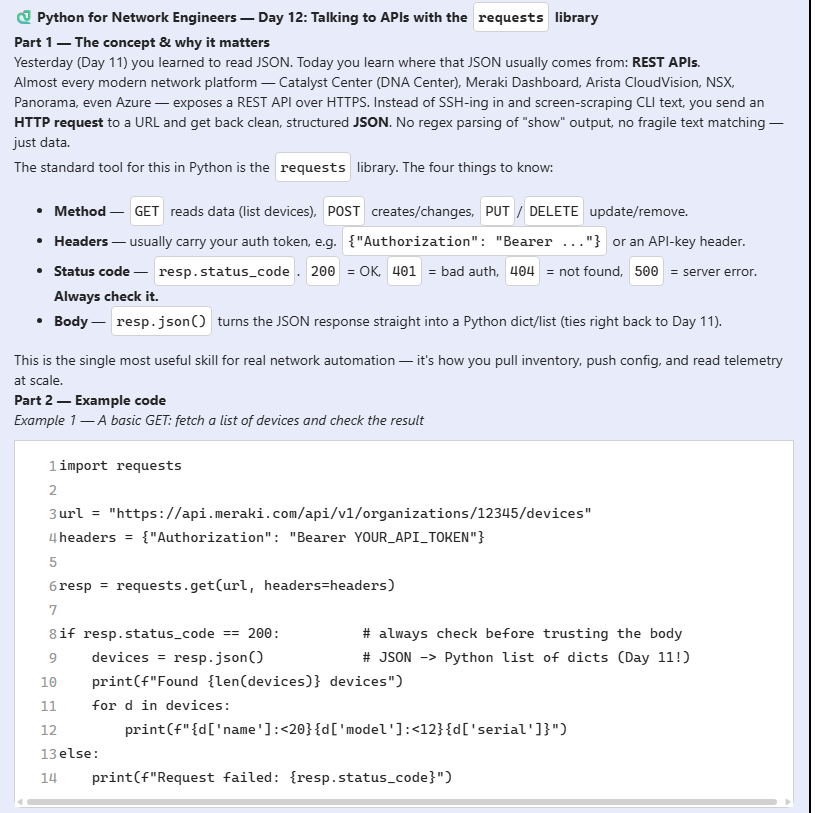

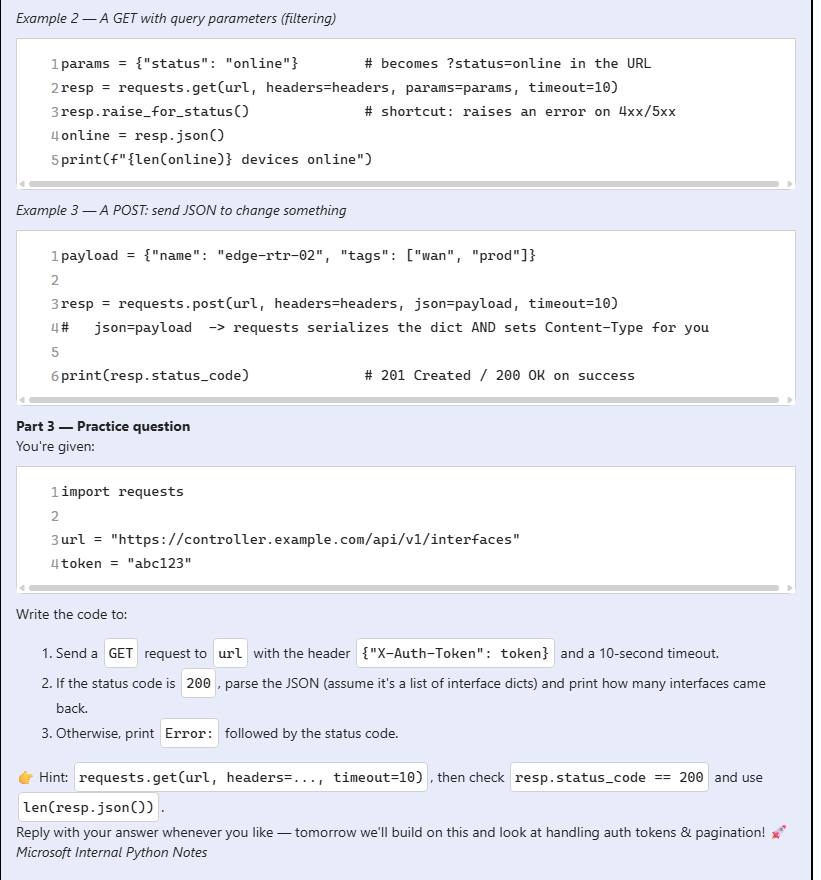


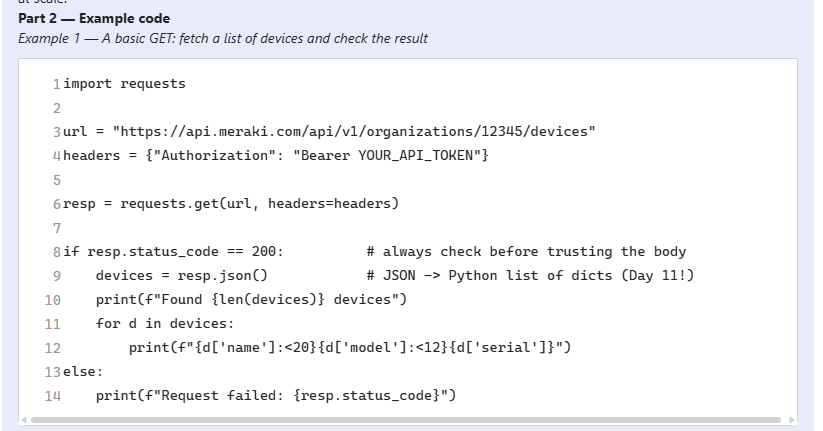



In [2]:

import requests

C:\Users\v-yaalam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


In [3]:
!pip install requests

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import requests

url = "https://api.meraki.com/api/v1/organizations/12345/devices"

headers = {"Authorization": "Bearer YOUR_API_TOKEN"}

resp = requests.get(url, headers=headers)

if resp.status_code == 200:
    devices = resp.json()
    print(f"Found {len(devices)} devices")
    for d in devices:
        print(f"{d['name']:<20} {d['model']:<12}{d['serial']}")
else:
    print(f"Request failed: {resp.status_code}")

Request failed: 401


In [6]:
import requests

url = "https://api.meraki.com/api/v1/organizations/12345/devices"
headers = {"Authorization": "Bearer YOUR_API_TOKEN"}

resp = requests.get(url, headers=headers)

if resp.status_code == 200:          # always check before trusting the body
    devices = resp.json()            # JSON -> Python list of dicts (Day 11!)
    print(f"Found {len(devices)} devices")
    for d in devices:
        print(f"{d['name']:<20}{d['model']:<12}{d['serial']}")
else:
    print(f"Request failed: {resp.status_code}")

Request failed: 401


In [13]:
import requests

url = "https://api.meraki.com/api/v1/organizations/12345/devices"

headers = {"Authorization": "Bearer YOUR_API_TOKEN"}

resp = requests.get(url, headers=headers)

if resp.status_code == 200:
    devices = resp.json()
    print(f"Found {len(devices)} devices")

    for d in devices:
        print(f"{d['name']:<20} {d['model']:<12} {d['serial']}")
else:
    print(f"Request failed: {resp.status_code}")

Request failed: 401


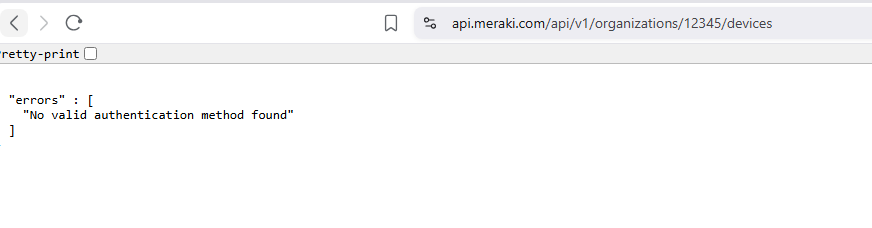



https://api.meraki.com/api/v1/organizations/12345/devices



https://httpbin.org/get


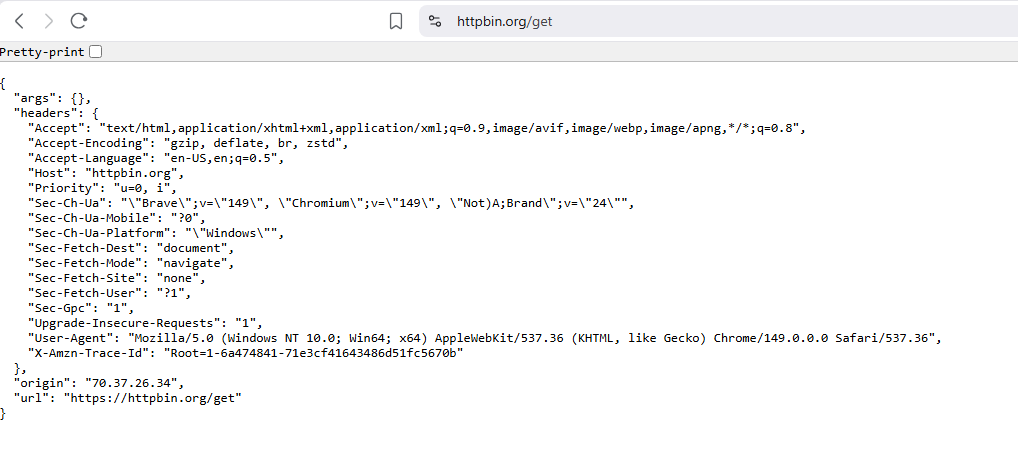

In [7]:
import requests

url = "https://httpbin.org/get"
headers = {"Authorization": "Bearer YOUR_API_TOKEN"}

resp = requests.get(url, headers=headers)

if resp.status_code == 200:          # always check before trusting the body
    devices = resp.json()            # JSON -> Python list of dicts (Day 11!)
    print(f"Found {len(devices)} devices")
    for d in devices:
        print(f"{d['name']:<20}{d['model']:<12}{d['serial']}")
else:
    print(f"Request failed: {resp.status_code}")



Found 4 devices


TypeError: string indices must be integers, not 'str'

In [8]:
import requests

url = "https://httpbin.org/get"

resp = requests.get(url)

print("Status Code:", resp.status_code)

if resp.status_code == 200:
    print(resp.json())

Status Code: 200
{'args': {}, 'headers': {'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate', 'Host': 'httpbin.org', 'User-Agent': 'python-requests/2.32.5', 'X-Amzn-Trace-Id': 'Root=1-6a4748a2-5eb1955a5c725b9c2d7a3859'}, 'origin': '70.37.26.37', 'url': 'https://httpbin.org/get'}


In [9]:
import requests

url = "https://jsonplaceholder.typicode.com/posts/1"

resp = requests.get(url)

print("Status Code:", resp.status_code)

if resp.status_code == 200:
    print(resp.json())

Status Code: 200
{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}


In [10]:
import requests

url = "https://api.ipify.org?format=json"

resp = requests.get(url)

print(resp.status_code)
print(resp.json())

200
{'ip': '70.37.26.38'}


In [11]:
import requests

url = "https://api.github.com"

resp = requests.get(url)

print(resp.status_code)

200



Great example for learning Python and APIs. Let me explain it **line by line** as if you're a network engineer just starting with REST APIs.

> **Note:** The URL in your example contains HTML tags (`<a href=...>`). In Python, it should be a plain string.

### Correct Version

```python
import requests

url = "https://api.meraki.com/api/v1/organizations/12345/devices"

headers = {"Authorization": "Bearer YOUR_API_TOKEN"}

resp = requests.get(url, headers=headers)

if resp.status_code == 200:
    devices = resp.json()
    print(f"Found {len(devices)} devices")

    for d in devices:
        print(f"{d['name']:<20} {d['model']:<12} {d['serial']}")
else:
    print(f"Request failed: {resp.status_code}")
```

***

# Line 1

```python
import requests
```

### What it does

Imports the **requests** library.

### Why we need it

`requests` allows Python to communicate with web servers and APIs.

Think of it as:

```text
Python Script ----HTTP Request----> Meraki API
Python Script <---HTTP Response---- Meraki API
```

Without importing `requests`, Python doesn't know how to send HTTP GET/POST requests.

***

# Line 3

```python
url = "https://api.meraki.com/api/v1/organizations/12345/devices"
```

### What it does

Stores the API endpoint in a variable called `url`.

### Breakdown

```text
https://
```

Protocol (secure HTTP)

```text
api.meraki.com
```

Meraki API server

```text
/api/v1
```

API version 1

```text
/organizations/12345
```

Organization ID

```text
/devices
```

Resource you want to retrieve

Meaning:

```text
Give me all devices in organization 12345
```

***

# Line 5

```python
headers = {"Authorization": "Bearer YOUR_API_TOKEN"}
```

### What it does

Creates a Python dictionary containing HTTP headers.

A dictionary looks like:

```python
{
    "key": "value"
}
```

In this case:

```python
{
    "Authorization": "Bearer YOUR_API_TOKEN"
}
```

***

### Why Authorization?

Meraki doesn't allow anonymous users.

The API needs proof of identity.

Think of it like SSH:

```text
SSH username/password
```

For APIs:

```text
Bearer Token
```

Example:

```python
Authorization: Bearer abc123xyz
```

***

### Header Structure

Key:

```python
"Authorization"
```

Value:

```python
"Bearer YOUR_API_TOKEN"
```

"Bearer" tells the server:

```text
I am presenting a token for authentication
```

***

# Line 7

```python
resp = requests.get(url, headers=headers)
```

### What it does

Sends an HTTP GET request.

Equivalent curl command:

```bash
curl -H "Authorization: Bearer TOKEN" \
https://api.meraki.com/api/v1/organizations/12345/devices
```

***

### GET Means

```text
GET = Read data
POST = Create data
PUT = Update data
DELETE = Remove data
```

You are requesting:

```text
Read all devices
```

***

### What gets returned?

The server replies with:

```text
Status Code
Headers
Response Body
```

Stored in variable:

```python
resp
```

Think:

```text
resp = server reply
```

***

# Line 9

```python
if resp.status_code == 200:
```

### What it does

Checks whether the request succeeded.

***

### Common Status Codes

| Code | Meaning      |
| ---- | ------------ |
| 200  | Success      |
| 201  | Created      |
| 400  | Bad Request  |
| 401  | Unauthorized |
| 403  | Forbidden    |
| 404  | Not Found    |
| 500  | Server Error |

***

Example:

```python
print(resp.status_code)
```

Output:

```text
200
```

Means:

```text
Server understood request and returned data
```

***

# Line 10

```python
devices = resp.json()
```

### What it does

Converts JSON from the API into Python objects.

Suppose Meraki returns:

```json
[
    {
        "name": "Switch1",
        "model": "MS250",
        "serial": "Q2AA-1111"
    },
    {
        "name": "Switch2",
        "model": "MS350",
        "serial": "Q2AA-2222"
    }
]
```

Python converts it to:

```python
[
    {
        "name":"Switch1",
        "model":"MS250",
        "serial":"Q2AA-1111"
    },
    {
        "name":"Switch2",
        "model":"MS350",
        "serial":"Q2AA-2222"
    }
]
```

So:

```python
devices
```

becomes a **list of dictionaries**.

***

# Line 11

```python
print(f"Found {len(devices)} devices")
```

### What is len()?

Returns the number of items.

Example:

```python
devices = ["SW1", "SW2", "SW3"]
```

```python
len(devices)
```

returns:

```python
3
```

Output:

```text
Found 3 devices
```

***

# Line 13

```python
for d in devices:
```

### What it does

Loops through every device.

Suppose:

```python
devices = [
    {"name":"SW1"},
    {"name":"SW2"},
    {"name":"SW3"}
]
```

Loop execution:

```text
1st iteration -> d = SW1
2nd iteration -> d = SW2
3rd iteration -> d = SW3
```

***

# Line 14

```python
print(f"{d['name']:<20} {d['model']:<12} {d['serial']}")
```

This is an **f-string**.

***

## d\['name']

Gets device name.

Example:

```python
d = {
    "name":"CoreSwitch",
    "model":"MS250",
    "serial":"ABC123"
}
```

```python
d['name']
```

returns:

```text
CoreSwitch
```

***

## d\['model']

Returns:

```text
MS250
```

***

## d\['serial']

Returns:

```text
ABC123
```

***

## What does `<20` mean?

Left align in a field width of 20 characters.

Example:

```python
print(f"{'CoreSwitch':<20}")
```

Output:

```text
CoreSwitch
```

with spaces added after it.

***

### Why useful?

Keeps columns aligned.

Output:

```text
CoreSwitch          MS250       ABC123
EdgeSwitch          MS350       XYZ456
AccessSwitch        MS120       DEF789
```

Instead of messy output:

```text
CoreSwitch MS250 ABC123
EdgeSwitch MS350 XYZ456
AccessSwitch MS120 DEF789
```

***

# Else Block

```python
else:
```

Runs when status code is NOT 200.

***

# Last Line

```python
print(f"Request failed: {resp.status_code}")
```

Examples:

```text
Request failed: 401
```

Meaning:

```text
Invalid API token
```

or

```text
Request failed: 404
```

Meaning:

```text
Wrong URL
```

***

# Flow Diagram

```text
Start
  |
  v
Import requests
  |
  v
Store URL
  |
  v
Create Auth Header
  |
  v
Send GET Request
  |
  v
Check Status Code
  |
  +----200?----Yes----+
  |                   |
  |                   v
  |           Convert JSON
  |                   |
  |                   v
  |           Count Devices
  |                   |
  |                   v
  |            Loop Devices
  |                   |
  |                   v
  |             Print Details
  |
  No
  |
  v
Print Error Code
```

**Network Automation Analogy:** This is exactly how you'll interact with REST APIs for Meraki, Cisco DNA Center, Cisco NSO, Arista CVP, Azure, and many SD-WAN controllers: **authenticate → send request → verify status code → parse JSON → loop through results.** This pattern appears in nearly every network automation script.





In [17]:
import requests

url = "https://api.meraki.com/api/v1/organizations/12345/devices"

headers = {
    "Authorization": "Bearer YOUR_API_TOKEN"
}

try:
    resp = requests.get(url, headers=headers)

    if resp.status_code == 200:
        devices = resp.json()

        print(f"Found {len(devices)} devices")

        for d in devices:
            print(f"{d['name']:<20} {d['model']:<12} {d['serial']}")

    else:
        print(f"API returned error: {resp.status_code}")

except Exception as e:
    print(f"Unexpected error: {e}")

API returned error: 401


In [16]:
import requests

try:
    resp = requests.get(
        url,
        headers=headers,
        timeout=10
    )

except requests.exceptions.ConnectionError:
    print("Cannot reach the API server")

except requests.exceptions.Timeout:
    print("Request timed out")

except requests.exceptions.RequestException as e:
    print(f"Request failed: {e}")


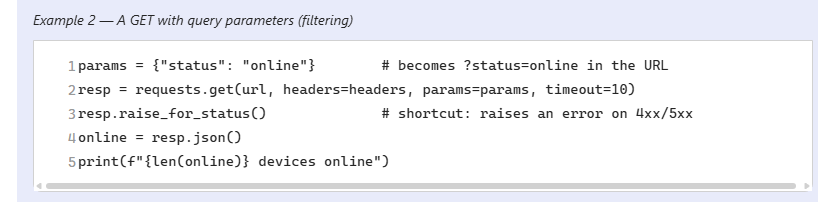

In [18]:
params = {"status":"online"}
resp = requests.get(url, headers=headers, params= params, timeout=10)
resp.raise_for_status()
online = resp.json()
print(f"{len(online)} devices online")

HTTPError: 401 Client Error: Unauthorized for url: https://api.meraki.com/api/v1/organizations/12345/devices?status=online

In [19]:
import requests

url = "https://api.meraki.com/api/v1/organizations"

headers = {
    "Authorization": "Bearer YOUR_REAL_API_KEY"
}

try:
    resp = requests.get(url, headers=headers, timeout=10)

    print("Status Code:", resp.status_code)

    resp.raise_for_status()

    data = resp.json()
    print(data)

except requests.exceptions.HTTPError as e:
    print("HTTP Error:", e)
    print("Response:", resp.text)

except Exception as e:
    print("Error:", e)

Status Code: 401
HTTP Error: 401 Client Error: Unauthorized for url: https://api.meraki.com/api/v1/organizations
Response: {
  "errors" : [
    "No valid authentication method found"
  ]
}



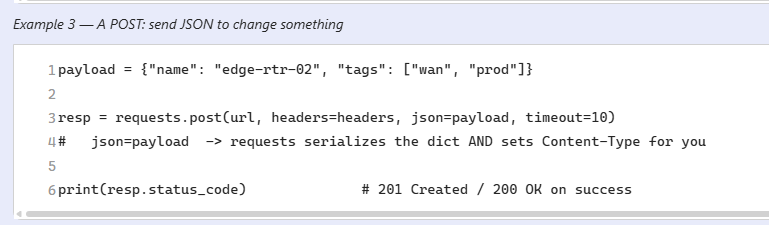

In [20]:
payload = {"name": "edge-rtr-02", "tags":["wan", "prod"]}

resp = requests.post(url, headers=headers, json=payload, timeout=10)

print(resp.status_code)

401


In [21]:
payload = {"name": "edge-rtr-02", "tags": ["wan", "prod"]}

resp = requests.post(url, headers=headers, json=payload, timeout=10)
#   json=payload  -> requests serializes the dict AND sets Content-Type for you

print(resp.status_code)              # 201 Created / 200 OK on success

401


In [22]:
payload = {"name": "edge-rtr-02", "tags":["wan", "prod"]}

resp = requests.post(url, headers=headers, json=payload, timeout=10)

if resp.status_code in (200, 201):
    print("Success!")
else:
    print("Failed:", resp.status_code)
    print(resp.text)

Failed: 401
{
  "errors" : [
    "No valid authentication method found"
  ]
}



In [23]:
payload = {"name": "edge-rtr-02", "tags":["wan", "prod"]}

resp = requests.post(url, headers=headers, json=payload, timeout=10)

if resp.status_code is 200:
    print("Success!")
else:
    print("Failed:", resp.status_code)
    print(resp.text)

<>:5: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
<>:5: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?


Failed: 401
{
  "errors" : [
    "No valid authentication method found"
  ]
}



C:\Users\v-yaalam\AppData\Local\Temp\ipykernel_42040\2486209200.py:5: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  if resp.status_code is 200:


In [24]:
payload = {"name": "edge-rtr-02", "tags":["wan", "prod"]}

resp = requests.post(url, headers=headers, json=payload, timeout=10)

if resp.status_code == 200:
    print("Success!")
else:
    print("Failed:", resp.status_code)
    print(resp.text)

Failed: 401
{
  "errors" : [
    "No valid authentication method found"
  ]
}



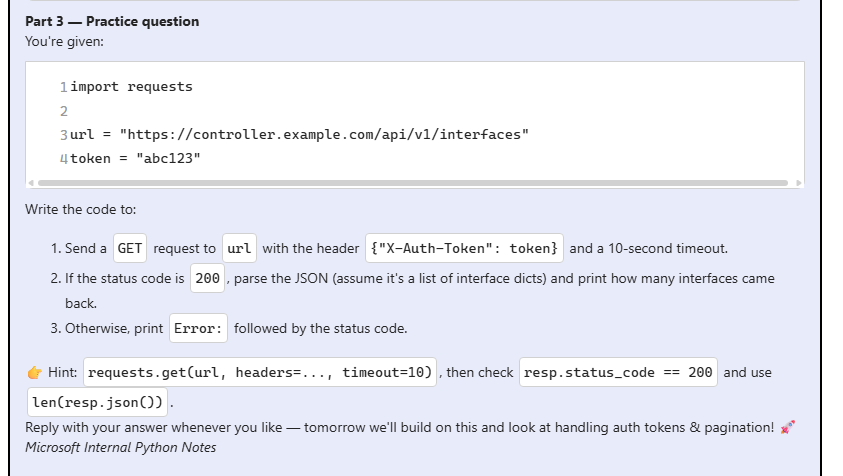

https://jsonplaceholder.typicode.com/users

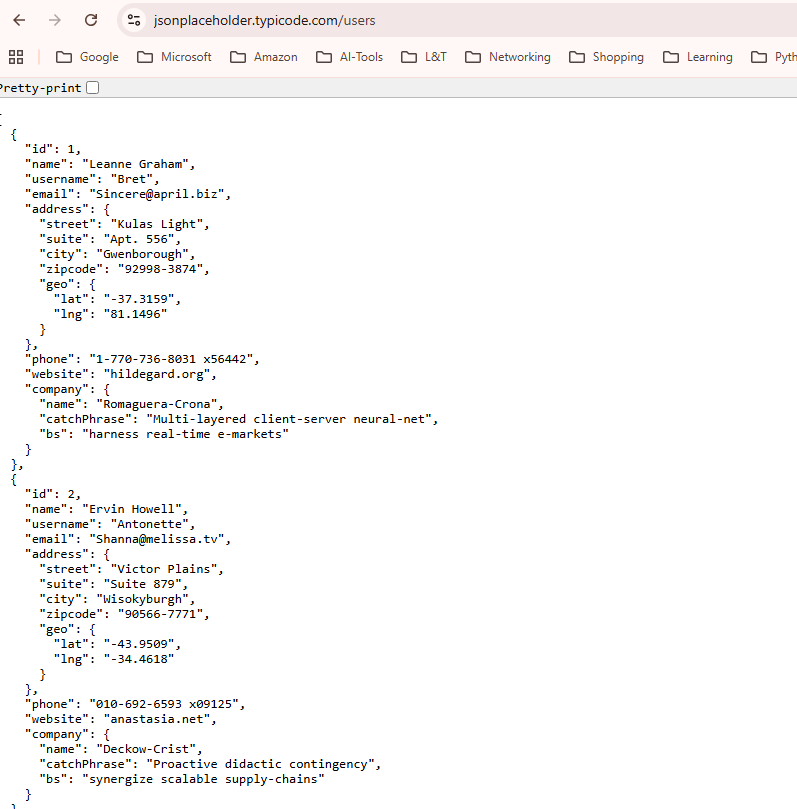


In [28]:
import requests

url = "https://jsonplaceholder.typicode.com/users"
resp = requests.get(url)

print(resp.status_code)
print(resp.json)



200
<bound method Response.json of <Response [200]>>


In [29]:
import requests

url = "https://jsonplaceholder.typicode.com/users"
resp = requests.get(url)

print(resp.status_code)
print(resp.json())



200
[{'id': 1, 'name': 'Leanne Graham', 'username': 'Bret', 'email': 'Sincere@april.biz', 'address': {'street': 'Kulas Light', 'suite': 'Apt. 556', 'city': 'Gwenborough', 'zipcode': '92998-3874', 'geo': {'lat': '-37.3159', 'lng': '81.1496'}}, 'phone': '1-770-736-8031 x56442', 'website': 'hildegard.org', 'company': {'name': 'Romaguera-Crona', 'catchPhrase': 'Multi-layered client-server neural-net', 'bs': 'harness real-time e-markets'}}, {'id': 2, 'name': 'Ervin Howell', 'username': 'Antonette', 'email': 'Shanna@melissa.tv', 'address': {'street': 'Victor Plains', 'suite': 'Suite 879', 'city': 'Wisokyburgh', 'zipcode': '90566-7771', 'geo': {'lat': '-43.9509', 'lng': '-34.4618'}}, 'phone': '010-692-6593 x09125', 'website': 'anastasia.net', 'company': {'name': 'Deckow-Crist', 'catchPhrase': 'Proactive didactic contingency', 'bs': 'synergize scalable supply-chains'}}, {'id': 3, 'name': 'Clementine Bauch', 'username': 'Samantha', 'email': 'Nathan@yesenia.net', 'address': {'street': 'Douglas E

In [27]:
import requests

url = "https://jsonplaceholder.typicode.com/users"
resp = requests.get(url)

print(resp.status_code)
print(resp.json)

if resp.status_code == 200:
    print(resp.json())




200
<bound method Response.json of <Response [200]>>
[{'id': 1, 'name': 'Leanne Graham', 'username': 'Bret', 'email': 'Sincere@april.biz', 'address': {'street': 'Kulas Light', 'suite': 'Apt. 556', 'city': 'Gwenborough', 'zipcode': '92998-3874', 'geo': {'lat': '-37.3159', 'lng': '81.1496'}}, 'phone': '1-770-736-8031 x56442', 'website': 'hildegard.org', 'company': {'name': 'Romaguera-Crona', 'catchPhrase': 'Multi-layered client-server neural-net', 'bs': 'harness real-time e-markets'}}, {'id': 2, 'name': 'Ervin Howell', 'username': 'Antonette', 'email': 'Shanna@melissa.tv', 'address': {'street': 'Victor Plains', 'suite': 'Suite 879', 'city': 'Wisokyburgh', 'zipcode': '90566-7771', 'geo': {'lat': '-43.9509', 'lng': '-34.4618'}}, 'phone': '010-692-6593 x09125', 'website': 'anastasia.net', 'company': {'name': 'Deckow-Crist', 'catchPhrase': 'Proactive didactic contingency', 'bs': 'synergize scalable supply-chains'}}, {'id': 3, 'name': 'Clementine Bauch', 'username': 'Samantha', 'email': 'Nath

In [31]:
import requests

url = "https://jsonplaceholder.typicode.com/users"
token = "abc123"

headers = {
    "X-Auth-Token": token
}

resp = requests.get(url, headers=headers, timeout = 10)

if resp.status_code == 200:
    data = resp.json()
    print(f"received {len(data)} records")
else:
    print(f"Error: {resp.status_code}")



received 10 records


In [32]:
import requests

url = "https://jsonplaceholder.typicode.com/users"

resp = requests.get(url, timeout=10)

if resp.status_code == 200:
    print(len(resp.json()))
else:
    print(f"Error: {resp.status_code}")

10


https://dummyjson.com/users

In [1]:
import requests

url = "https://dummyjson.com/users"

resp = requests.get(url, timeout=10)

if resp.status_code == 200:
    print(len(resp.json()))
else:
    print(f"Error: {resp.status_code}")

C:\Users\v-yaalam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


4
